<a href="https://colab.research.google.com/github/Nguza/AI-Project-Portfolio-/blob/main/Assignment_8_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import RFE
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report

)

In [ ]:
data = load_breast_cancer()

data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [ ]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y= data.target

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

X_train

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
68,9.029,17.33,58.79,250.5,0.10660,0.14130,0.31300,0.04375,0.2111,0.08046,0.3274,1.1940,1.8850,17.67,0.009549,0.086060,0.303800,0.033220,0.04197,0.009559,10.310,22.65,65.50,324.7,0.14820,0.43650,1.25200,0.17500,0.4228,0.11750
181,21.090,26.57,142.70,1311.0,0.11410,0.28320,0.24870,0.14960,0.2395,0.07398,0.6298,0.7629,4.4140,81.46,0.004253,0.047590,0.038720,0.015670,0.01798,0.005295,26.680,33.48,176.50,2089.0,0.14910,0.75840,0.67800,0.29030,0.4098,0.12840
63,9.173,13.86,59.20,260.9,0.07721,0.08751,0.05988,0.02180,0.2341,0.06963,0.4098,2.2650,2.6080,23.52,0.008738,0.039380,0.043120,0.015600,0.04192,0.005822,10.010,19.23,65.59,310.1,0.09836,0.16780,0.13970,0.05087,0.3282,0.08490
248,10.650,25.22,68.01,347.0,0.09657,0.07234,0.02379,0.01615,0.1897,0.06329,0.2497,1.4930,1.4970,16.64,0.007189,0.010350,0.010810,0.006245,0.02158,0.002619,12.250,35.19,77.98,455.7,0.14990,0.13980,0.11250,0.06136,0.3409,0.08147
60,10.170,14.88,64.55,311.9,0.11340,0.08061,0.01084,0.01290,0.2743,0.06960,0.5158,1.4410,3.3120,34.62,0.007514,0.010990,0.007665,0.008193,0.04183,0.005953,11.020,17.45,69.86,368.6,0.12750,0.09866,0.02168,0.02579,0.3557,0.08020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,8.888,14.64,58.79,244.0,0.09783,0.15310,0.08606,0.02872,0.1902,0.08980,0.5262,0.8522,3.1680,25.44,0.017210,0.093680,0.056710,0.017660,0.02541,0.021930,9.733,15.67,62.56,284.4,0.12070,0.24360,0.14340,0.04786,0.2254,0.10840
106,11.640,18.33,75.17,412.5,0.11420,0.10170,0.07070,0.03485,0.1801,0.06520,0.3060,1.6570,2.1550,20.62,0.008540,0.023100,0.029450,0.013980,0.01565,0.003840,13.140,29.26,85.51,521.7,0.16880,0.26600,0.28730,0.12180,0.2806,0.09097
270,14.290,16.82,90.30,632.6,0.06429,0.02675,0.00725,0.00625,0.1508,0.05376,0.1302,0.7198,0.8439,10.77,0.003492,0.003710,0.004826,0.003608,0.01536,0.001381,14.910,20.65,94.44,684.6,0.08567,0.05036,0.03866,0.03333,0.2458,0.06120
435,13.980,19.62,91.12,599.5,0.10600,0.11330,0.11260,0.06463,0.1669,0.06544,0.2208,0.9533,1.6020,18.85,0.005314,0.017910,0.021850,0.009567,0.01223,0.002846,17.040,30.80,113.90,869.3,0.16130,0.35680,0.40690,0.18270,0.3179,0.10550


Baseline Model

In [ ]:
print("\n====== BASELINE MODEL (Logictic Regression) ======")

baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=500))
])

baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)


====== BASELINE MODEL (Logictic Regression) ======


In [ ]:
y_pred

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0])

Hypermarameter Tuning

In [ ]:
print ("\n====== HYPERMARAMETER TUNING ======")

param_grid = {
    'model__C': [0.01, 0,1, 1, 10],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs']


}

grid_search = GridSearchCV(
    baseline_model,
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]



====== HYPERMARAMETER TUNING ======
Best Parameters: {'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
5 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **last

In [ ]:
y_prob_tuned

array([8.86409750e-01, 9.00936206e-06, 3.07909541e-03, 9.99489866e-01,
       9.99939361e-01, 9.48087773e-11, 1.53672648e-09, 3.49030633e-02,
       6.20657860e-01, 9.99240597e-01, 9.50128217e-01, 1.24071210e-02,
       9.93926181e-01, 1.43930883e-01, 9.98378244e-01, 7.40182295e-04,
       9.98147541e-01, 9.99988834e-01, 9.99999182e-01, 1.11701472e-06,
       9.15836610e-01, 9.90252217e-01, 4.33732393e-09, 9.99921081e-01,
       9.98861257e-01, 9.99415413e-01, 9.98925555e-01, 9.94024817e-01,
       9.97146883e-01, 8.18296669e-06, 9.99482590e-01, 9.99851240e-01,
       9.97839056e-01, 9.94505862e-01, 9.99859294e-01, 9.97576657e-01,
       5.75840151e-02, 9.97101296e-01, 8.87859084e-05, 9.51863624e-01,
       9.99928757e-01, 4.06608387e-04, 9.97533594e-01, 9.99036115e-01,
       9.80010795e-01, 9.28445266e-01, 9.99601428e-01, 9.99509374e-01,
       9.69530199e-01, 9.99385984e-01, 1.20346382e-04, 5.31315374e-08,
       6.91788480e-01, 9.86770623e-01, 9.99972637e-01, 9.90454756e-01,
      

In [ ]:
y_pred_tuned

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0])

In [ ]:
param_grid = {
    'model__C': [1],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs']


}

grid_search = GridSearchCV(
    baseline_model,
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]


Best Parameters: {'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}


Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

print("\n====== HYPERMARAMETER TUNING - RANDOMIZED SEARCH ======")

param_dist = {
    'model__C': np.logspace(-3, 3, 50),
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs']

}

random_search = RandomizedSearchCV(
    baseline_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Parameters (RandomizedSearch):", random_search.best_params_)
print("Best CV Score (RandomizedSearch):", random_search.best_score_)

best_model_random = random_search.best_estimator_


====== HYPERMARAMETER TUNING - RANDOMIZED SEARCH ======
Best Parameters (RandomizedSearch): {'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__C': np.float64(4.714866363457395)}
Best CV Score (RandomizedSearch): 0.9780219780219781


Regularization (L1 vs L2)

In [ ]:
print("\n====== REGULARIZATION COMPARISON ======")

l1_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(penalty='l1', solver='liblinear', max_iter=500))
])

l2_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(penalty='l2', solver='lbfgs', max_iter=500))
])

l1_model.fit(X_train, y_train)
l2_model.fit(X_train, y_train)




====== REGULARIZATION COMPARISON ======


Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=500))])

Ensemble Models

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

print("\n====== ENSEMBLE MODELS ======")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)
ada_model.fit(X_train, y_train)

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    }


====== ENSEMBLE MODELS ======


Model Comparison


====== MODEL COMPARISON ======
               Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0           Baseline  0.973684   0.972222  0.985915  0.979021  0.997380
1              Tuned  0.973684   0.972222  0.985915  0.979021  0.997380
2  L1 Regularization  0.973684   0.985714  0.971831  0.978723  0.996725
3  L2 Regularization  0.973684   0.972222  0.985915  0.979021  0.997380
4      Random Forest  0.964912   0.958904  0.985915  0.972222  0.995251
5           AdaBoost  0.973684   0.972222  0.985915  0.979021  0.994432


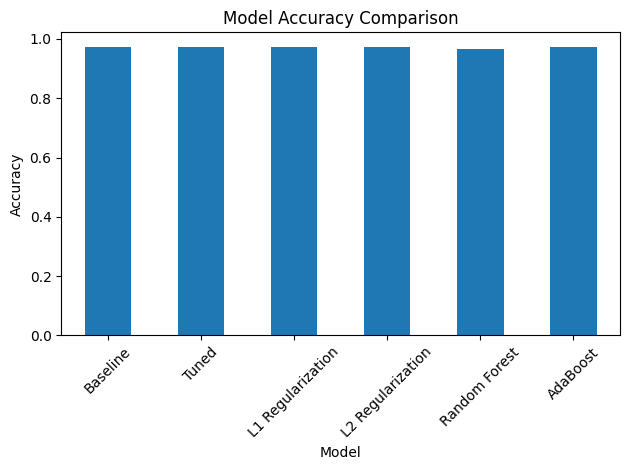

In [ ]:
results = []

results.append(evaluate_model("Baseline", baseline_model, X_test, y_test))
results.append(evaluate_model("Tuned", best_model, X_test, y_test))
results.append(evaluate_model("L1 Regularization", l1_model, X_test, y_test))
results.append(evaluate_model("L2 Regularization", l2_model, X_test, y_test))
results.append(evaluate_model("Random Forest", rf_model, X_test, y_test))
results.append(evaluate_model("AdaBoost", ada_model, X_test, y_test))

results_df = pd.DataFrame(results)
print("\n====== MODEL COMPARISON ======")
print(results_df)

results_df.set_index("Model")["Accuracy"].plot(kind="bar")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ROC-AUC Scores & Curves (Grid vs Random)


====== ROC-AUC SCORES & CURVES ======
ROC AUC (GridSearchCV): 0.99737962659679
ROC AUC (RandomizedSearch Best Model): 0.9963969865705863


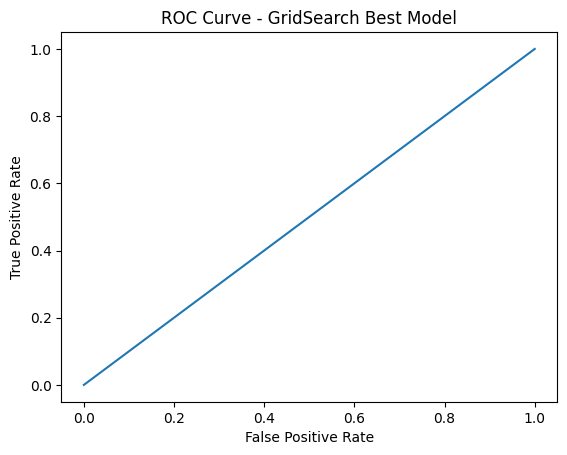

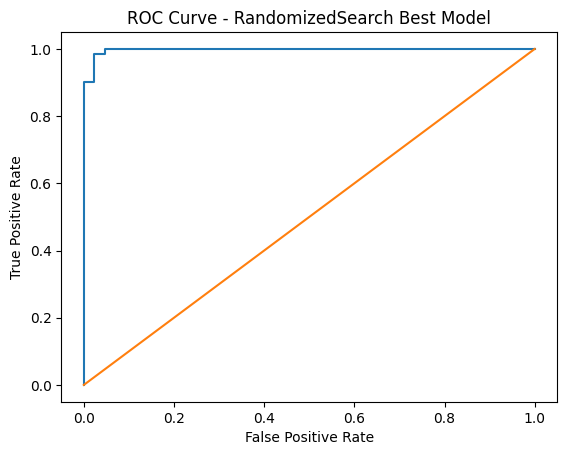

In [ ]:
from sklearn.metrics import roc_curve

print("\n====== ROC-AUC SCORES & CURVES ======")

y_prob_grid = best_model.predict_proba(X_test)[:, 1]
roc_auc_grid = roc_auc_score(y_test, y_prob_tuned)
print("ROC AUC (GridSearchCV):", roc_auc_grid)

y_prob_random = best_model_random.predict_proba(X_test)[:, 1]
roc_auc_random = roc_auc_score(y_test, y_prob_random)
print("ROC AUC (RandomizedSearch Best Model):", roc_auc_random)

fpr_grid, tpr_grid, _ = roc_curve(y_test, y_prob_tuned)
plt.figure()
plt.plot([0,1], [0,1])
plt.title("ROC Curve - GridSearch Best Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

fpr_random, tpr_random, _ = roc_curve(y_test, y_prob_tuned)
plt.figure()
plt.plot(fpr_random, tpr_random)
plt.plot([0,1], [0,1])
plt.title("ROC Curve - RandomizedSearch Best Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()